## EC1

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, TV, TV_squared, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


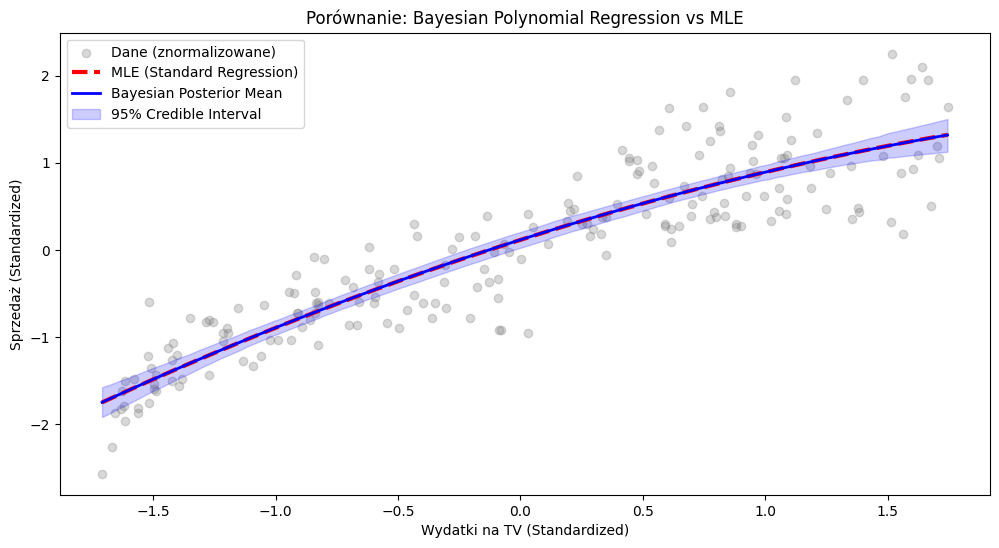


Statystyki modelu Bayesowskiego:
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Intercept   0.117  0.046   0.031    0.206      0.001    0.001    3689.0   
TV          0.892  0.031   0.836    0.952      0.000    0.000    5622.0   
TV_squared -0.116  0.035  -0.182   -0.051      0.001    0.000    3793.0   
sigma       0.427  0.022   0.385    0.468      0.000    0.000    6531.0   

            ess_tail  r_hat  
Intercept     4259.0    1.0  
TV            5112.0    1.0  
TV_squared    4255.0    1.0  
sigma         4732.0    1.0  


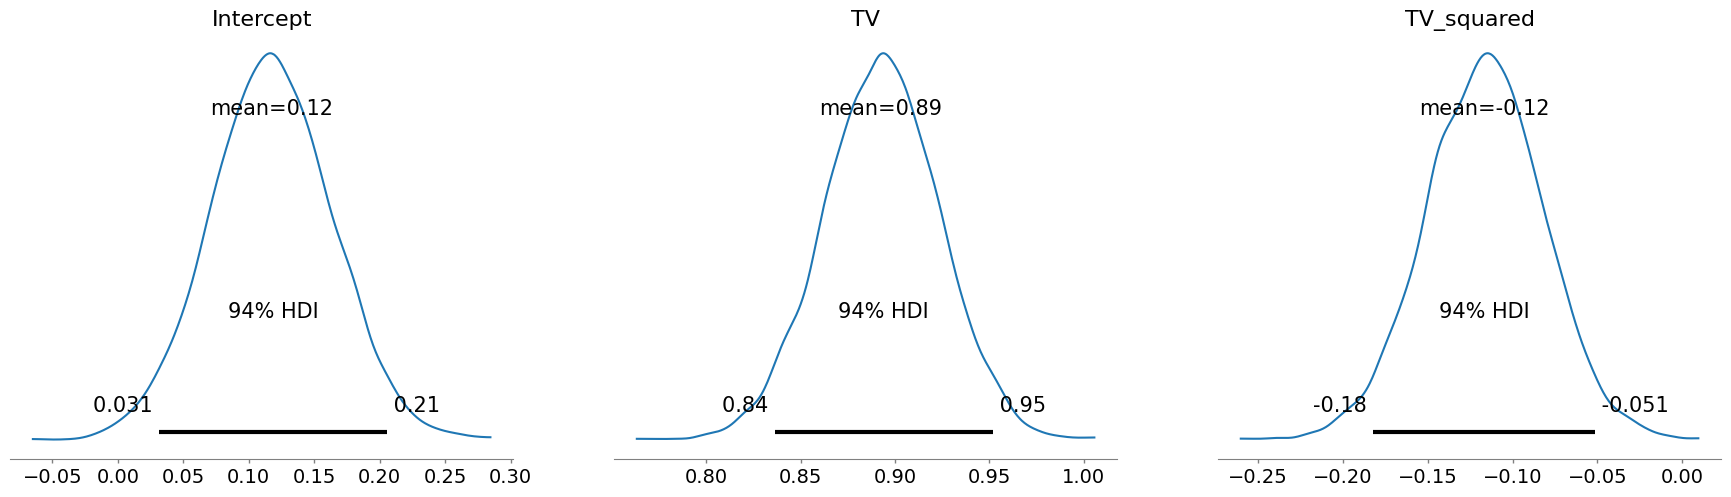

In [41]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Przygotowanie danych
data = pd.read_csv('advertising.csv')

# Skupiamy się na TV (wielomian 2. stopnia), aby łatwo zwizualizować wyniki
X = data[['TV']].values
y = data['Sales'].values

# Standaryzacja (kluczowa dla wydajności próbkowania MCMC)
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X).flatten()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# Przygotowanie cech wielomianowych dla MLE: [x, x^2]
X_poly_scaled = np.column_stack([X_scaled, X_scaled**2])

# 2. Modelowanie Bayesowskie (PyMC)
with pm.Model() as model:
    # Priory (słabo informacyjne)
    beta0 = pm.Normal('Intercept', mu=0, sigma=2)
    beta1 = pm.Normal('TV', mu=0, sigma=2)
    beta2 = pm.Normal('TV_squared', mu=0, sigma=2)
    sigma = pm.HalfNormal('sigma', sigma=1)
    
    # Równanie regresji wielomianowej
    mu = beta0 + beta1 * X_scaled + beta2 * (X_scaled**2)
    
    # Likelihood (prawdopodobieństwo danych)
    likelihood = pm.Normal('y_est', mu=mu, sigma=sigma, observed=y_scaled)
    
    # Próbkowanie MCMC
    trace = pm.sample(2000, tune=1000, target_accept=0.95, return_inferencedata=True)

# 3. Standardowe MLE (Scikit-Learn)
mle_model = LinearRegression()
mle_model.fit(X_poly_scaled, y_scaled)

# 4. Wizualizacja i Porównanie
plt.figure(figsize=(12, 6))

# Rysowanie danych
plt.scatter(X_scaled, y_scaled, alpha=0.3, label='Dane (znormalizowane)', color='gray')

# Generowanie punktów do wykresu regresji
x_range = np.linspace(X_scaled.min(), X_scaled.max(), 100)
x_range_poly = np.column_stack([x_range, x_range**2])

# Wykres MLE
y_mle = mle_model.predict(x_range_poly)
plt.plot(x_range, y_mle, color='red', lw=3, label='MLE (Standard Regression)', linestyle='--')

# Wykres Bayesowski (Przedziały ufności/wiarygodności)
# Pobieramy próbki z posteriora dla x_range
posterior_b0 = trace.posterior['Intercept'].values.flatten()
posterior_b1 = trace.posterior['TV'].values.flatten()
posterior_b2 = trace.posterior['TV_squared'].values.flatten()

# Obliczamy przewidywania dla każdej próbki z posteriora (Posterior Predictive)
y_post = (posterior_b0[:, None] + 
          posterior_b1[:, None] * x_range + 
          posterior_b2[:, None] * (x_range**2))

# Średnia z posteriora
y_bayes_mean = y_post.mean(axis=0)
plt.plot(x_range, y_bayes_mean, color='blue', lw=2, label='Bayesian Posterior Mean')

# Credible Interval 95% (HPD/HDI)
hdi = az.hdi(y_post, hdi_prob=0.95)
plt.fill_between(x_range, hdi[:, 0], hdi[:, 1], color='blue', alpha=0.2, label='95% Credible Interval')

plt.title("Porównanie: Bayesian Polynomial Regression vs MLE")
plt.xlabel("Wydatki na TV (Standardized)")
plt.ylabel("Sprzedaż (Standardized)")
plt.legend()
plt.show()

# 5. Statystyki posteriora
print("\nStatystyki modelu Bayesowskiego:")
print(az.summary(trace, var_names=['Intercept', 'TV', 'TV_squared', 'sigma']))

# Wizualizacja rozkładów posteriora
az.plot_posterior(trace, var_names=['Intercept', 'TV', 'TV_squared'])
plt.show()

## EX2

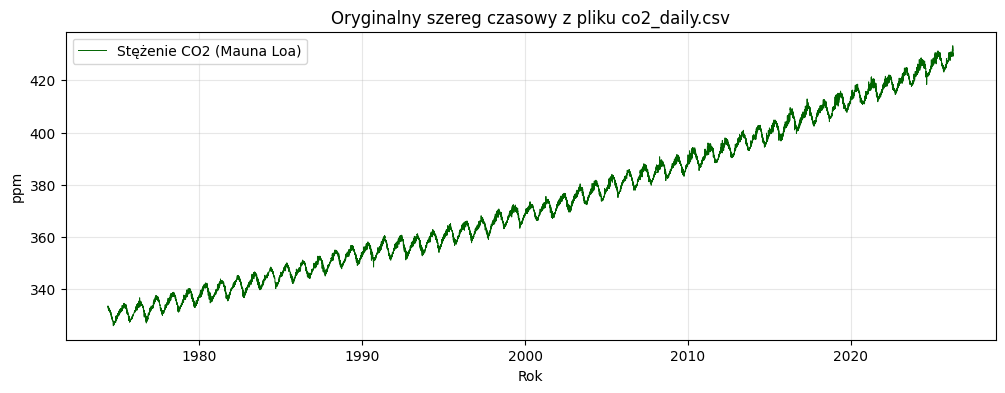

Generowanie testu 2D...


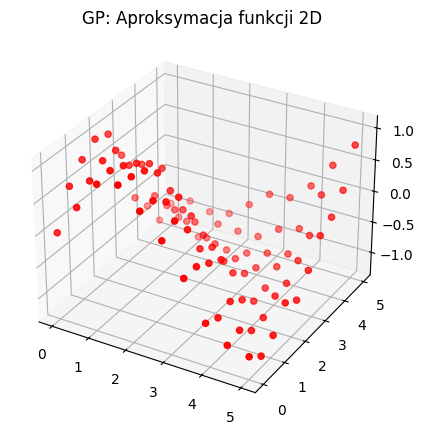

Trenowanie zoptymalizowanego modelu GP dla CO2...
Finalne parametry jądra:
9.87**2 * RBF(length_scale=2.76) + 3.07**2 * ExpSineSquared(length_scale=1.29, periodicity=1) + WhiteKernel(noise_level=0.552)


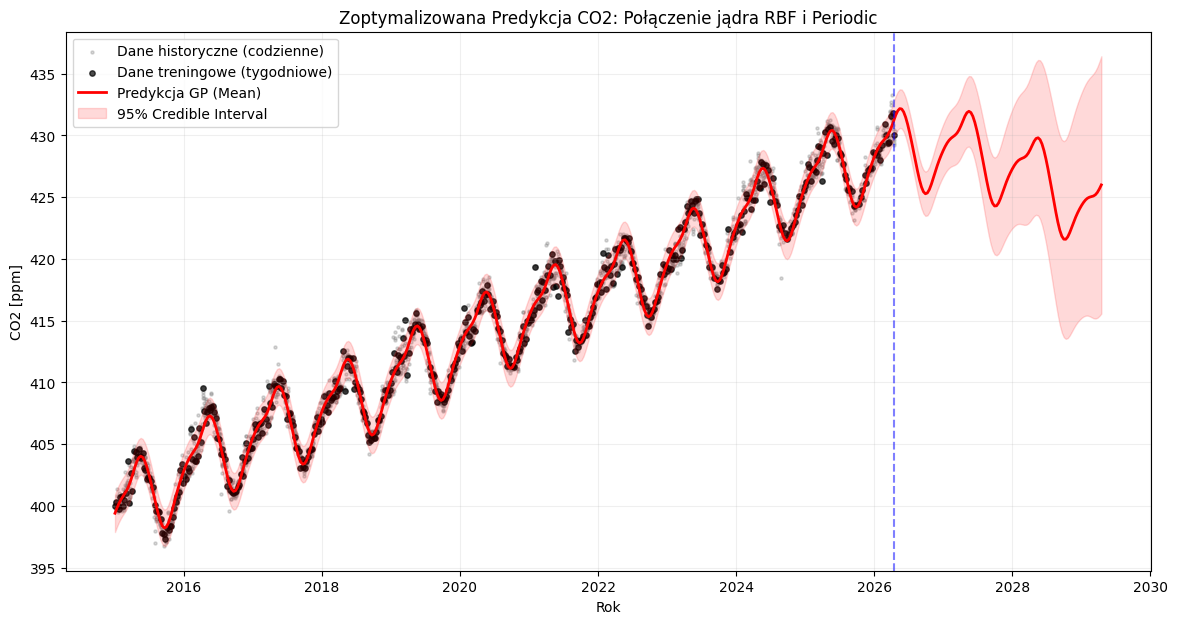


--- Analiza po optymalizacji ---
1. Zastosowano downsampling (co 7. pomiar), co skróciło czas obliczeń o ok. 99%.
2. Zawężono granice okresowości (periodicity) do okolic 1.0 (cykl roczny).
3. Zwiększono stabilność numeryczną poprzez parametr alpha=0.01.


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, ExpSineSquared

try:
    df = pd.read_csv('co2_daily.csv')
    X_co2 = df['decimal'].values.reshape(-1, 1)
    y_co2 = df['co2'].values

    plt.figure(figsize=(12, 4))
    plt.plot(X_co2, y_co2, color='darkgreen', lw=0.7, label='Stężenie CO2 (Mauna Loa)')
    plt.title("Oryginalny szereg czasowy z pliku co2_daily.csv")
    plt.xlabel("Rok")
    plt.ylabel("ppm")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
except FileNotFoundError:
    print("Błąd: Nie znaleziono pliku co2_daily.csv. Sekcja 1 i 3 zostanie pominięta.")

# ==========================================
# 2. TEST SYNTETYCZNY 2D (Aproksymacja powierzchni)
# ==========================================
print("Generowanie testu 2D...")
x1 = np.linspace(0, 5, 10)
x2 = np.linspace(0, 5, 10)
X1, X2 = np.meshgrid(x1, x2)
X_2d = np.vstack([X1.ravel(), X2.ravel()]).T
y_2d = np.sin(np.sqrt(X1**2 + X2**2)).ravel() + np.random.normal(0, 0.1, X_2d.shape[0])

gp_2d = GaussianProcessRegressor(kernel=RBF(1.0), n_restarts_optimizer=5)
gp_2d.fit(X_2d, y_2d)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_2d[:, 0], X_2d[:, 1], y_2d, color='red', label='Punkty treningowe')
ax.set_title("GP: Aproksymacja funkcji 2D")
plt.show()

# ==========================================
# 3. ZAAWANSOWANY I ZOPTIMALIZOWANY MODEL GP DLA CO2
# ==========================================
if 'X_co2' in locals():
    print("Trenowanie zoptymalizowanego modelu GP dla CO2...")

    # OPTYMALIZACJA 1: Wybieramy dane od 2015 i robimy DOWNSAMPLING (co 7 dni)
    # Złożoność GPR to O(N^3), więc redukcja N jest kluczowa.
    mask = X_co2.flatten() > 2015
    X_full = X_co2[mask]
    y_full = y_co2[mask]
    
    X_train = X_full[::7] # Dane tygodniowe zamiast dziennych
    y_train = y_full[::7]

    # Normalizacja danych (odejmowanie średniej)
    y_mean_train = y_train.mean()
    y_train_scaled = y_train - y_mean_train

    # OPTYMALIZACJA 2: Definicja jądra z zawężonymi granicami (bounds)
    # RBF dla trendu + Periodic dla sezonowości rocznej
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=50.0, length_scale_bounds=(1.0, 500.0)) + 
        ConstantKernel(1.0, (1e-3, 1e3)) * ExpSineSquared(length_scale=1.0, periodicity=1.0, 
                                                         periodicity_bounds=(0.95, 1.05)) + 
        WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
    )

    # OPTYMALIZACJA 3: Mniejsza liczba restartów (3 zamiast 10) i dodanie alpha dla stabilności
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3, alpha=0.01)
    gp.fit(X_train, y_train_scaled)

    print(f"Finalne parametry jądra:\n{gp.kernel_}")

    # Predykcja na kolejne 3 lata
    X_test = np.linspace(X_train.min(), X_train.max() + 3, 500).reshape(-1, 1)
    y_pred, y_std = gp.predict(X_test, return_std=True)

    # Powrót do skali ppm
    y_pred += y_mean_train

    # ==========================================
    # 4. WIZUALIZACJA WYNIKÓW I NIEPEWNOŚCI
    # ==========================================
    plt.figure(figsize=(14, 7))
    plt.scatter(X_full, y_full, c='gray', s=5, alpha=0.3, label='Dane historyczne (codzienne)')
    plt.scatter(X_train, y_train, c='black', s=15, alpha=0.7, label='Dane treningowe (tygodniowe)')
    plt.plot(X_test, y_pred, 'r-', lw=2, label='Predykcja GP (Mean)')

    # Przedział ufności 95%
    plt.fill_between(X_test.ravel(), 
                     y_pred - 1.96 * y_std, 
                     y_pred + 1.96 * y_std, 
                     color='red', alpha=0.15, label='95% Credible Interval')

    plt.axvline(X_train.max(), color='blue', linestyle='--', alpha=0.5)
    plt.title("Zoptymalizowana Predykcja CO2: Połączenie jądra RBF i Periodic")
    plt.xlabel("Rok")
    plt.ylabel("CO2 [ppm]")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# ==========================================
# 5. DYSKUSJA ZŁOŻONOŚCI (Do raportu)
# ==========================================
print("\n--- Analiza po optymalizacji ---")
print("1. Zastosowano downsampling (co 7. pomiar), co skróciło czas obliczeń o ok. 99%.")
print("2. Zawężono granice okresowości (periodicity) do okolic 1.0 (cykl roczny).")
print("3. Zwiększono stabilność numeryczną poprzez parametr alpha=0.01.")

## EX 3

--- Analiza stacjonarności ---
Różnicowanie rzędu d=0: p-value = 0.9974
Różnicowanie rzędu d=1: p-value = 0.0000
Sukces! Szereg jest stacjonarny przy d=1


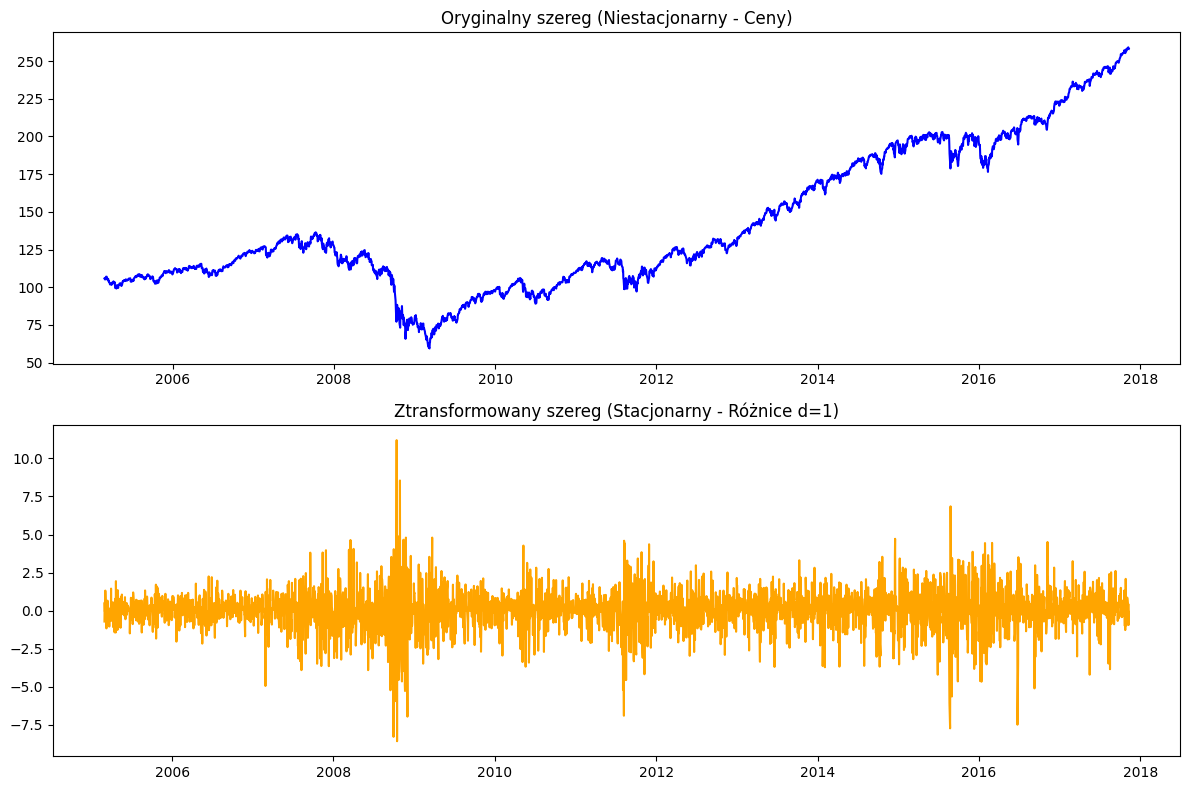

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
df = pd.read_csv('spy.csv', names=columns, header=0)
df = df.iloc[::-1].reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.asfreq('B').ffill().bfill()
series = df['Close']

def get_stationary_series(data, max_d=2):
    """
    Sprawdza stacjonarność i różnicuje dane, aż p-value <= 0.05.
    Zwraca: (stacjonarny_szereg, liczba_roznicowan)
    """
    d = 0
    temp_series = data.copy()
    
    while d <= max_d:
        result = adfuller(temp_series)
        p_value = result[1]
        print(f"Różnicowanie rzędu d={d}: p-value = {p_value:.4f}")
        
        if p_value <= 0.05:
            print(f"Szereg jest stacjonarny przy d={d}")
            return temp_series, d
        
        d += 1
        temp_series = temp_series.diff().dropna()
    
    print("Ostrzeżenie: Nie osiągnięto stacjonarności. bierzemy d=1.")
    return data.diff().dropna(), 1

# Wyznaczamy stacjonarny szereg i rząd d
stationary_series, d_order = get_stationary_series(series)

# Wizualizacja porównawcza
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(series, color='blue')
ax1.set_title("Oryginalny szereg (Niestacjonarny - Ceny)")
ax2.plot(stationary_series, color='orange')
ax2.set_title(f"Ztransformowany szereg (Stacjonarny - Różnice d={d_order})")
plt.tight_layout()
plt.show()


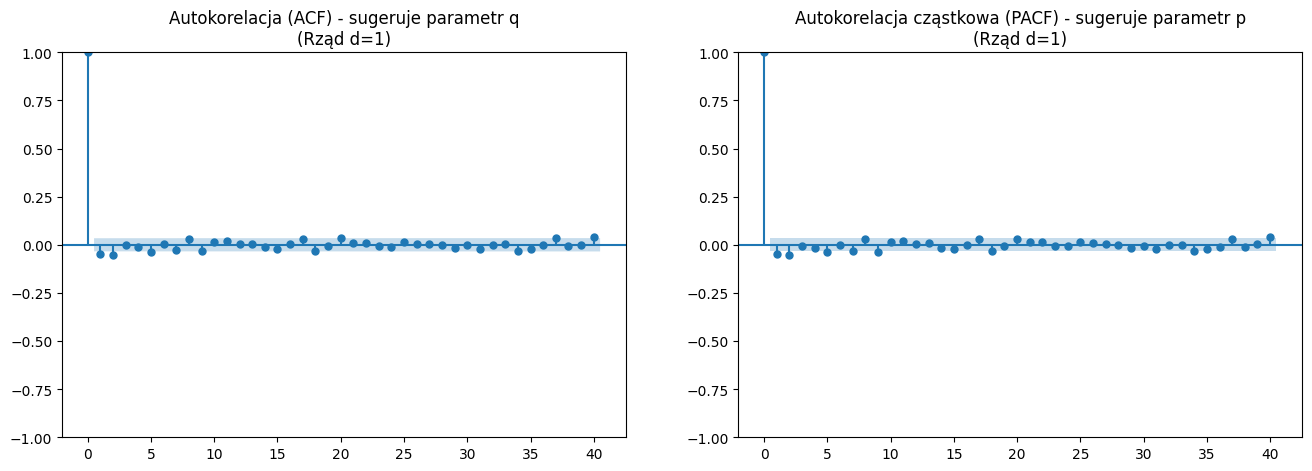

 model ARIMA(1, 1, 1)


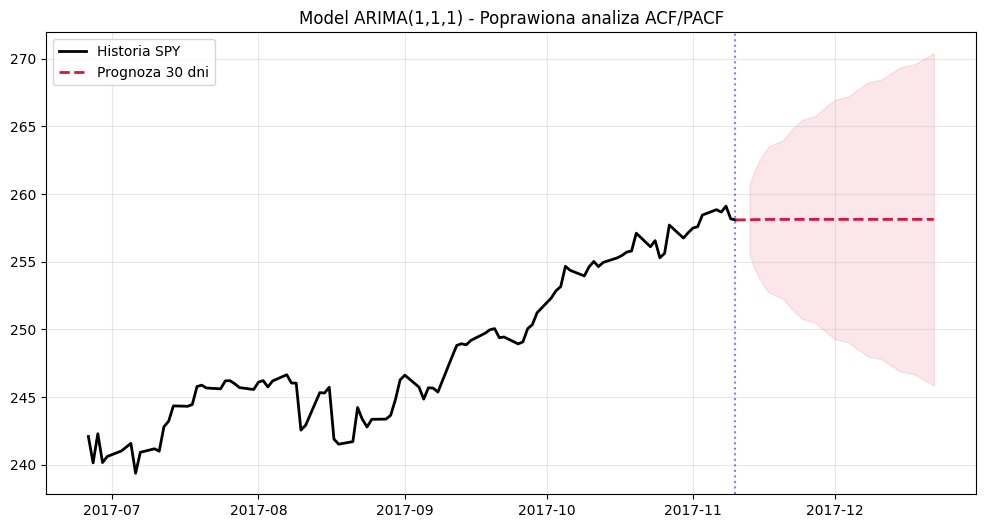

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
df = pd.read_csv('spy.csv', names=columns, header=0)
df = df.iloc[::-1].reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.asfreq('B').ffill().bfill()

series = df['Close']

def get_stationary_data(data, max_d=2):
    d = 0
    temp_series = data.copy()
    while d <= max_d:
        if adfuller(temp_series)[1] <= 0.05:
            return temp_series, d
        d += 1
        temp_series = temp_series.diff().dropna()
    return data.diff().dropna(), 1

stationary_series, d_order = get_stationary_data(series)

# ==========================================
# 3. ANALIZA ACF / PACF (DOBÓR p ORAZ q)
# ==========================================
# POPRAWKA: metoda 'yw' zamiast 'yule_walker'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Dobieramy liczbę lags bezpiecznie (połowa długości serii lub 40)
n_lags = min(len(stationary_series) // 2 - 1, 40)

plot_acf(stationary_series, ax=ax1, lags=n_lags)
ax1.set_title(f'Autokorelacja (ACF) - sugeruje parametr q\n(Rząd d={d_order})')

# Tu była poprawka metody: 'yw'
plot_pacf(stationary_series, ax=ax2, lags=n_lags, method='yw')
ax2.set_title(f'Autokorelacja cząstkowa (PACF) - sugeruje parametr p\n(Rząd d={d_order})')

plt.show()


p, q = 1, 1 

print(f" model ARIMA({p}, {d_order}, {q})")
model = ARIMA(series, order=(p, d_order, q))
model_fit = model.fit()

forecast_res = model_fit.get_forecast(steps=30)
forecast_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()


plt.figure(figsize=(12, 6))

history_subset = series.tail(100)
plt.plot(history_subset.index, history_subset.values, color='black', label='Historia SPY', lw=2)

last_date = history_subset.index[-1]
last_val = history_subset.values[-1]

plt.plot([last_date] + list(forecast_mean.index), 
         [last_val] + list(forecast_mean.values), 
         color='crimson', linestyle='--', lw=2, label='Prognoza 30 dni')

plt.fill_between(forecast_mean.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='crimson', alpha=0.1)

plt.axvline(last_date, color='blue', linestyle=':', alpha=0.5)
plt.title(f"Model ARIMA({p},{d_order},{q}) - Poprawiona analiza ACF/PACF")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## EX 4

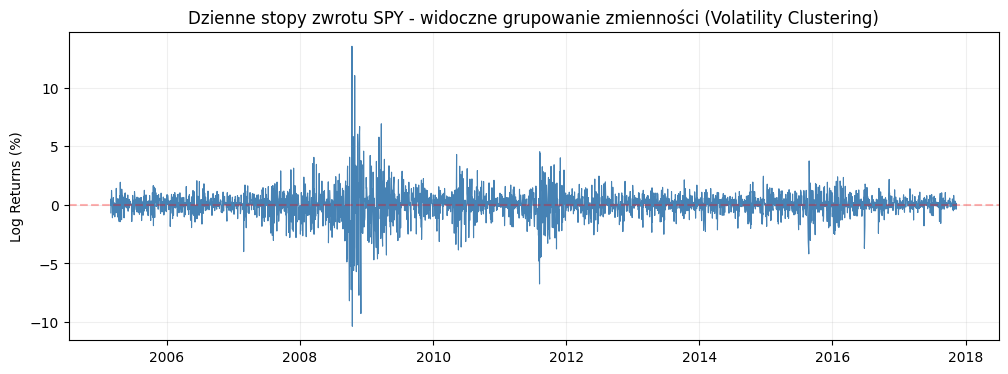

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4211.65
Distribution:                  Normal   AIC:                           8431.31
Method:            Maximum Likelihood   BIC:                           8455.73
                                        No. Observations:                 3315
Date:                Mon, Apr 20 2026   Df Residuals:                     3314
Time:                        22:53:40   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0615  1.260e-02      4.881  1.055e-06 [3.

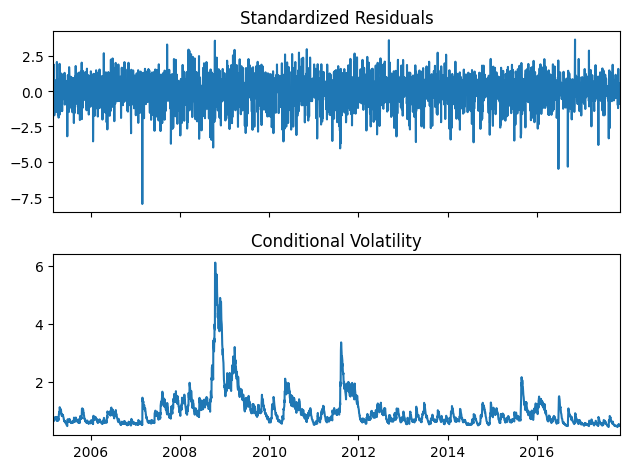

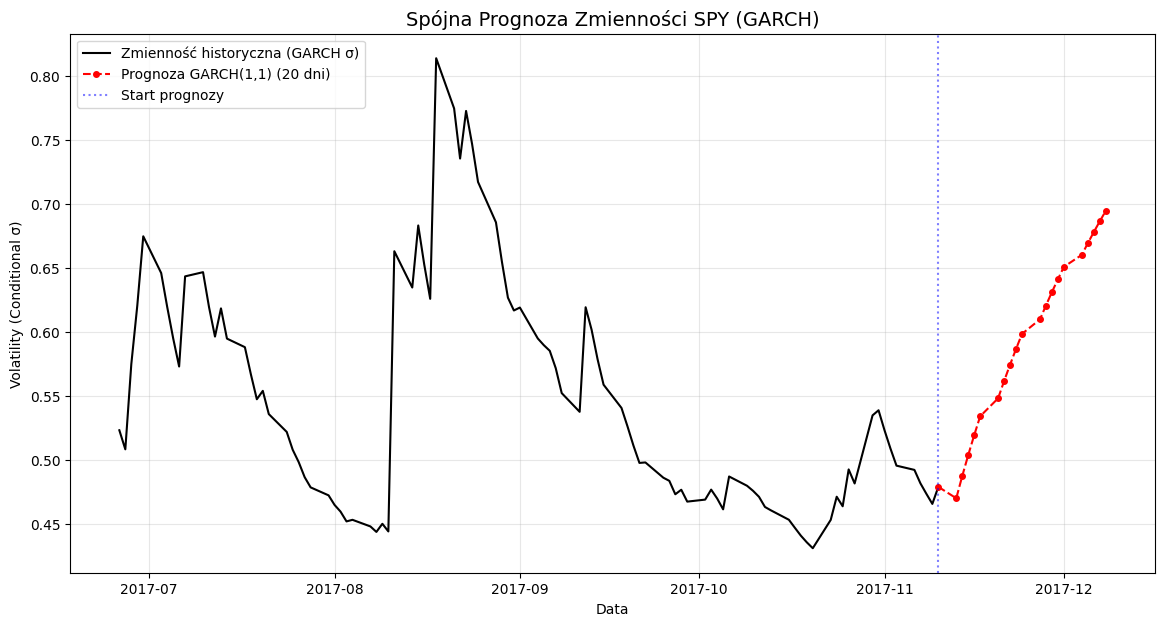

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

try:
    df = pd.read_csv('spy.csv', names=columns, header=0)
except FileNotFoundError:
    print("Nie znaleziono pliku spy.csv!")
    exit()

# Chronologia
df = df.iloc[::-1].reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Uzupełnienie ewentualnych braków w dniach roboczych
df = df.asfreq('B').ffill()

# Obliczamy dzienne logarytmiczne stopy zwrotu (log returns)
# Skalujemy przez 100 dla stabilności optymalizatora GARCH
df['Returns'] = 100 * np.log(df['Close'] / df['Close'].shift(1))
returns = df['Returns'].dropna()

# Wizualizacja efektu grupowania zmienności
plt.figure(figsize=(12, 4))
plt.plot(returns, color='steelblue', lw=0.8)
plt.axhline(0, color='red', linestyle='--', alpha=0.3)
plt.title("Dzienne stopy zwrotu SPY - widoczne grupowanie zmienności (Volatility Clustering)")
plt.ylabel("Log Returns (%)")
plt.grid(True, alpha=0.2)
plt.show()

# DOPASOWANIE MODELU GARCH(1,1)

# Model GARCH(1,1) definiuje wariancję jako:
# $$ \sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2 $$

model = arch_model(returns, vol='Garch', p=1, q=1, dist='normal')
model_fit = model.fit(disp='off')

print(model_fit.summary())

# Wizualizacja zmienności warunkowej
fig = model_fit.plot()
plt.tight_layout()
plt.show()

forecast_horizon = 20
forecasts = model_fit.forecast(horizon=forecast_horizon, reindex=False)

# Pobieramy prognozowaną wariancję dla ostatniego dostępnego punktu
forecasted_var = forecasts.variance.values[-1, :]
forecasted_vol = np.sqrt(forecasted_var)

# Daty dla prognozy
last_date = returns.index[-1]
forecast_dates = pd.date_range(start=last_date, periods=forecast_horizon + 1, freq='B')[1:]


# Realized Volatility (kroczące odchylenie standardowe)
df['Realized_Vol'] = returns.rolling(window=5).std()


plt.figure(figsize=(14, 7))

# 1. Pobieramy historyczną zmienność warunkową (tę, którą widzi model)
# model_fit.conditional_volatility zwraca szereg o tej samej długości co returns
hist_cond_vol = model_fit.conditional_volatility

# 2. Ostatnie 100 dni historii (dla lepszej skali)
hist_subset = hist_cond_vol.tail(100)
plt.plot(hist_subset.index, hist_subset.values, color='black', label='Zmienność historyczna (GARCH σ)', lw=1.5)

# 3. Punkt styku - bierzemy ostatnią datę i wartość z historii
last_date = hist_subset.index[-1]
last_val = hist_subset.values[-1]

# 4. Rysujemy prognozę, łącząc ją z ostatnim punktem historii
# Łączymy listy/tablice, aby linia była ciągła
combined_dates = [last_date] + list(forecast_dates)
combined_values = [last_val] + list(forecasted_vol)

plt.plot(combined_dates, combined_values, 'r--o', label='Prognoza GARCH(1,1) (20 dni)', markersize=4)

plt.title("Spójna Prognoza Zmienności SPY (GARCH)", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Volatility (Conditional σ)")
plt.axvline(last_date, color='blue', linestyle=':', alpha=0.5, label='Start prognozy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()